In [1]:
%matplotlib inline

# Spatial Statistics I — In-Class Demo
# Lecture 17 · Spring 2026

Topics covered:
  
  Part 1: Spatial Mapping with Python (geopandas, cartopy, xarray)

  Part 2: Spatial Statistics (G/F functions, permutation test)



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ══════════════════════════════════════════════════════════════════════════════
# PART 1 — SPATIAL MAPPING


# ─────────────────────────────────────────────────────────────────────────────
# 1a. Cartopy — World map with earthquake points


In [ ]:

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load real USGS earthquake catalog (M5.0+, 2020-2025)
# Source: https://earthquake.usgs.gov/fdsnws/event/1/
eq_df = pd.read_csv("earthquakes.csv", usecols=["time", "latitude", "longitude", "depth", "mag", "place"])
eq_df = eq_df.rename(columns={"mag": "magnitude", "depth": "depth_km"})
eq_df = eq_df.dropna(subset=["latitude", "longitude", "magnitude"])

/workspaces/.venv/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


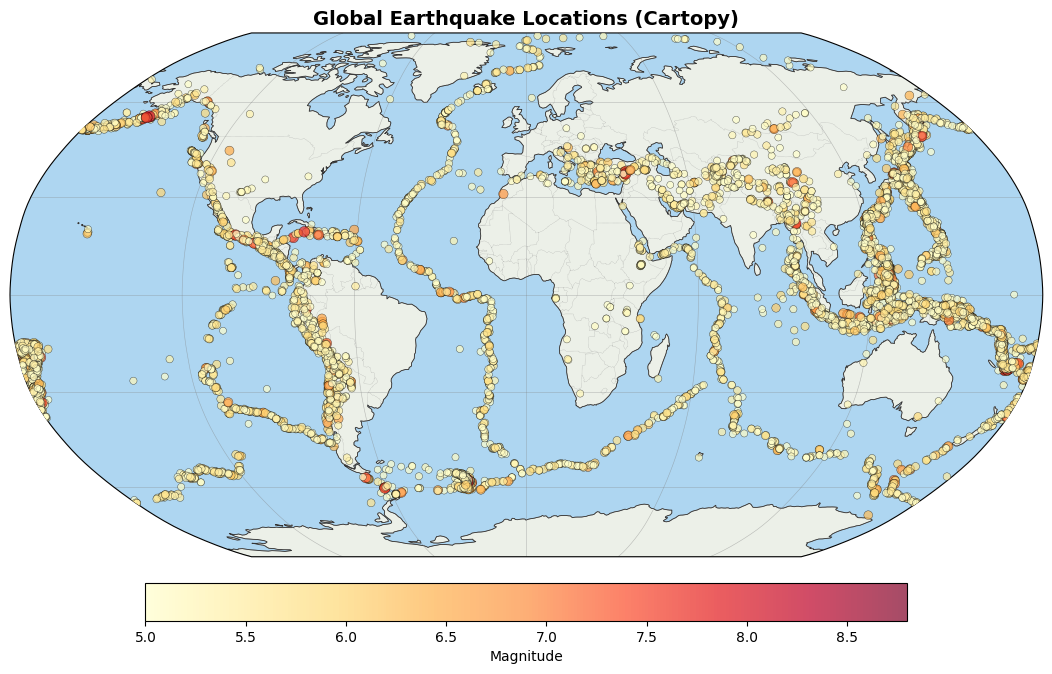

In [15]:
fig, ax = plt.subplots(figsize=(13, 7),
                        subplot_kw={"projection": ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.OCEAN,     facecolor="#AED6F1")
ax.add_feature(cfeature.LAND,      facecolor="#ECF0E8", edgecolor="#888888", linewidth=0.4)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color="#333333")
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":", color="#888888")
ax.gridlines(linewidth=0.4, color="gray", alpha=0.5)

sc = ax.scatter(
    eq_df["longitude"], eq_df["latitude"],
    c=eq_df["magnitude"], cmap="YlOrRd",
    s=eq_df["magnitude"] ** 2,              # size ~ magnitude²
    alpha=0.7, transform=ccrs.PlateCarree(),
    zorder=5, linewidths=0.3, edgecolors="black",
)
cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.04, shrink=0.6)
cbar.set_label("Magnitude")
ax.set_title("Global Earthquake Locations (Cartopy)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 1b. GeoPandas — vector data, buffer, spatial join


  Samples within 500m buffer: 9 / 60


/tmp/ipykernel_1721/1471704254.py:46: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", fontsize=9)


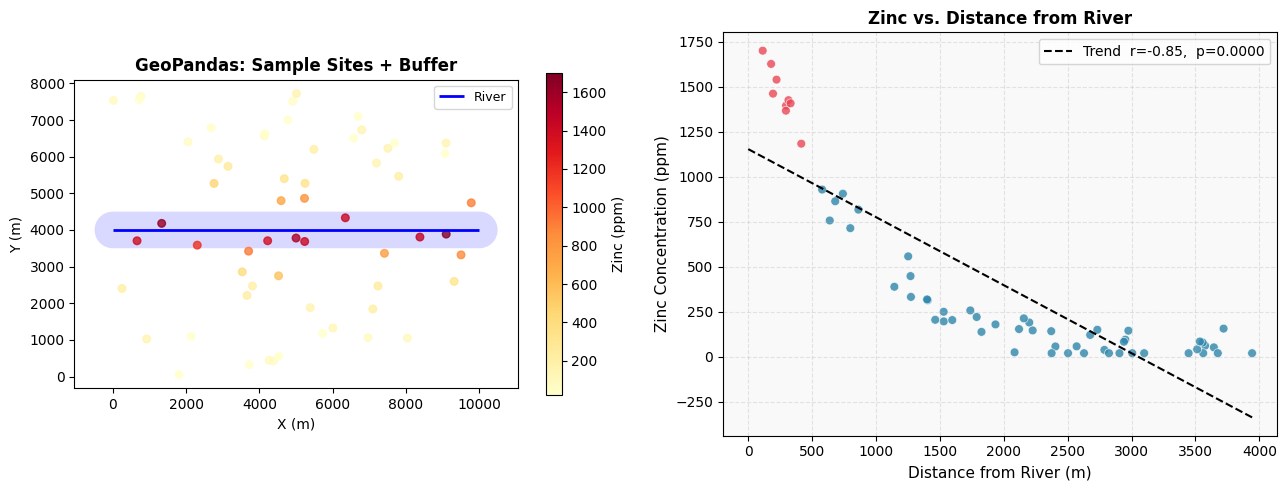

In [6]:
import geopandas as gpd
from shapely.geometry import Point, LineString

# Create a GeoDataFrame of sample sites along a synthetic river
np.random.seed(7)
n_samples = 60
x_vals = np.random.uniform(0, 10_000, n_samples)   # metres (projected CRS)
y_vals = np.random.uniform(0, 8_000, n_samples)

# Simulate zinc concentrations: higher near river (y ≈ 4000 m)
dist_river = np.abs(y_vals - 4000)
zinc = 2000 * np.exp(-dist_river / 800) + np.random.normal(0, 80, n_samples)
zinc = np.clip(zinc, 20, 2500)

gdf_samples = gpd.GeoDataFrame(
    {"zinc_ppm": zinc, "dist_river_m": dist_river},
    geometry=[Point(x, y) for x, y in zip(x_vals, y_vals)],
    crs="EPSG:28992",       # Dutch national grid (common for Meuse-type data)
)

# Define the river as a horizontal line at y=4000
river_line = LineString([(0, 4000), (10_000, 4000)])
gdf_river = gpd.GeoDataFrame(geometry=[river_line], crs="EPSG:28992")

# Create a 500-m buffer around the river
river_buffer = gdf_river.copy()
river_buffer["geometry"] = gdf_river.buffer(500)

# Spatial join: which samples fall within the buffer?
gdf_within = gpd.sjoin(gdf_samples, river_buffer, how="left", predicate="within")
gdf_samples["in_buffer"] = ~gdf_within["index_right"].isna()

print(f"  Samples within 500m buffer: {gdf_samples['in_buffer'].sum()} / {n_samples}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
gdf_river.plot(ax=ax, color="blue", linewidth=2, label="River")
river_buffer.plot(ax=ax, color="blue", alpha=0.15, label="500 m buffer")
gdf_samples.plot(ax=ax, column="zinc_ppm", cmap="YlOrRd",
                  legend=True, markersize=30, alpha=0.8,
                  legend_kwds={"label": "Zinc (ppm)", "shrink": 0.8})
ax.set_title("GeoPandas: Sample Sites + Buffer", fontsize=12, fontweight="bold")
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.legend(loc="upper right", fontsize=9)

ax2 = axes[1]
colors = ["#E84855" if v else "#2E86AB" for v in gdf_samples["in_buffer"]]
ax2.scatter(gdf_samples["dist_river_m"], gdf_samples["zinc_ppm"],
            c=colors, s=40, alpha=0.8, edgecolors="white", linewidth=0.5)
from scipy.stats import pearsonr
r, p = pearsonr(gdf_samples["dist_river_m"], gdf_samples["zinc_ppm"])
xs = np.linspace(0, dist_river.max(), 100)
z = np.polyfit(gdf_samples["dist_river_m"], gdf_samples["zinc_ppm"], 1)
ax2.plot(xs, np.poly1d(z)(xs), "k--", linewidth=1.5,
          label=f"Trend  r={r:.2f},  p={p:.4f}")
ax2.set_xlabel("Distance from River (m)", fontsize=11)
ax2.set_ylabel("Zinc Concentration (ppm)", fontsize=11)
ax2.set_title("Zinc vs. Distance from River", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.set_facecolor("#f9f9f9")
ax2.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PART 2 — SPATIAL STATISTICS


# ─────────────────────────────────────────────────────────────────────────────
# 2a. Generate three example point patterns

In [ ]:
from scipy.spatial.distance import cdist

np.random.seed(0)
N = 60

# ── Regular: grid with small jitter ──────────────────────────────────────────
grid_1d = np.linspace(0.05, 0.95, 8)
grid_pts = np.array([[x, y] for x in grid_1d for y in grid_1d])
idx = np.random.choice(len(grid_pts), N, replace=False)
pts_regular = np.clip(grid_pts[idx] + np.random.normal(0, 0.006, (N, 2)), 0, 1)

# ── Clustered: random cluster centers + Gaussian spread ──────────────────────
cluster_centers = np.random.uniform(0.1, 0.9, (8, 2))
cluster_pts = []
for c in cluster_centers:
    cluster_pts.extend(c + np.random.normal(0, 0.07, (N // 8, 2)))
pts_clustered = np.clip(np.array(cluster_pts[:N]), 0, 1)

# ── Random (CSR) ─────────────────────────────────────────────────────────────
pts_random = np.random.uniform(0, 1, (N, 2))

patterns = [
    ("Regular",   pts_regular,   "#2E86AB"),
    ("Clustered", pts_clustered, "#E84855"),
    ("Random",    pts_random,    "#3BB273"),
]


[2a] Generating three point patterns (regular / clustered / random)


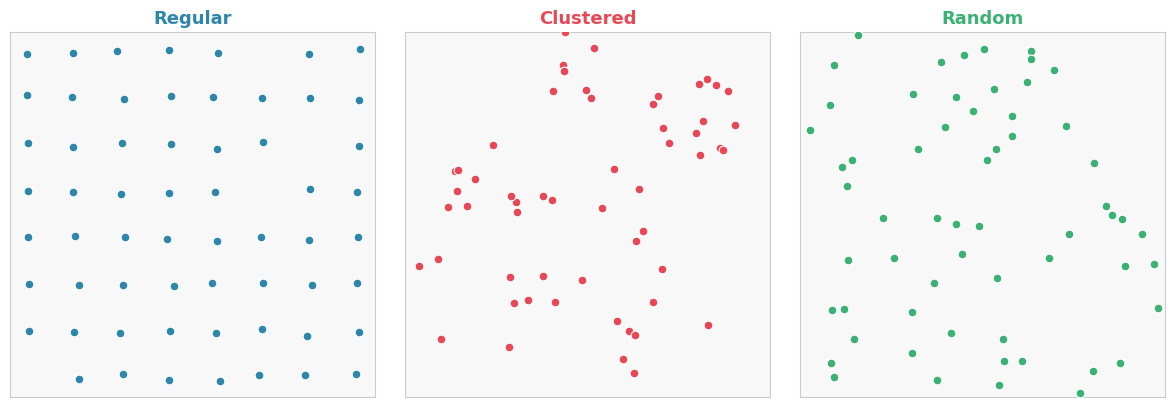

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor="white")
for ax, (name, pts, col) in zip(axes, patterns):
    ax.scatter(pts[:, 0], pts[:, 1], c=col, s=40,
                edgecolors="white", linewidth=0.8, zorder=3)
    ax.set_title(name, fontsize=13, fontweight="bold", color=col)
    ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor("#cccccc")
    ax.set_facecolor("#f8f8f8")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 2b. G function

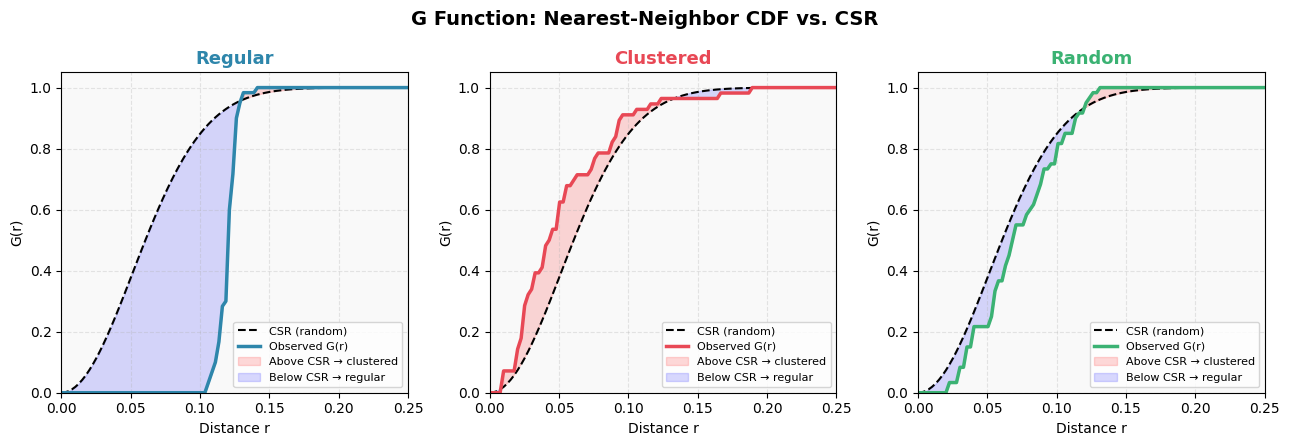

In [19]:
def g_function(points, r_max=0.25, n_bins=100):
    """Empirical G(r): CDF of nearest-neighbor distances."""
    D = cdist(points, points)
    np.fill_diagonal(D, np.inf)
    nnd = D.min(axis=1)
    r = np.linspace(0, r_max, n_bins)
    G = np.array([np.mean(nnd <= ri) for ri in r])
    return r, G

def g_csr(r, intensity):
    """Theoretical G(r) under Complete Spatial Randomness (CSR)."""
    return 1 - np.exp(-intensity * np.pi * r**2)

r_vals = np.linspace(0, 0.25, 100)
G_random_theory = g_csr(r_vals, intensity=N)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), facecolor="white")
for ax, (name, pts, col) in zip(axes, patterns):
    r, G_obs = g_function(pts)
    ax.plot(r_vals, G_random_theory, "k--", lw=1.5, label="CSR (random)")
    ax.plot(r, G_obs, color=col, lw=2.5, label="Observed G(r)")
    ax.fill_between(r, G_obs, g_csr(r, N),
                    where=(G_obs > g_csr(r, N)),
                    alpha=0.15, color="red",   label="Above CSR → clustered")
    ax.fill_between(r, G_obs, g_csr(r, N),
                    where=(G_obs < g_csr(r, N)),
                    alpha=0.15, color="blue",  label="Below CSR → regular")
    ax.set_title(name, fontsize=13, fontweight="bold", color=col)
    ax.set_xlabel("Distance r"); ax.set_ylabel("G(r)")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 0.25); ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_facecolor("#f9f9f9")

fig.suptitle("G Function: Nearest-Neighbor CDF vs. CSR", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 2c. F function

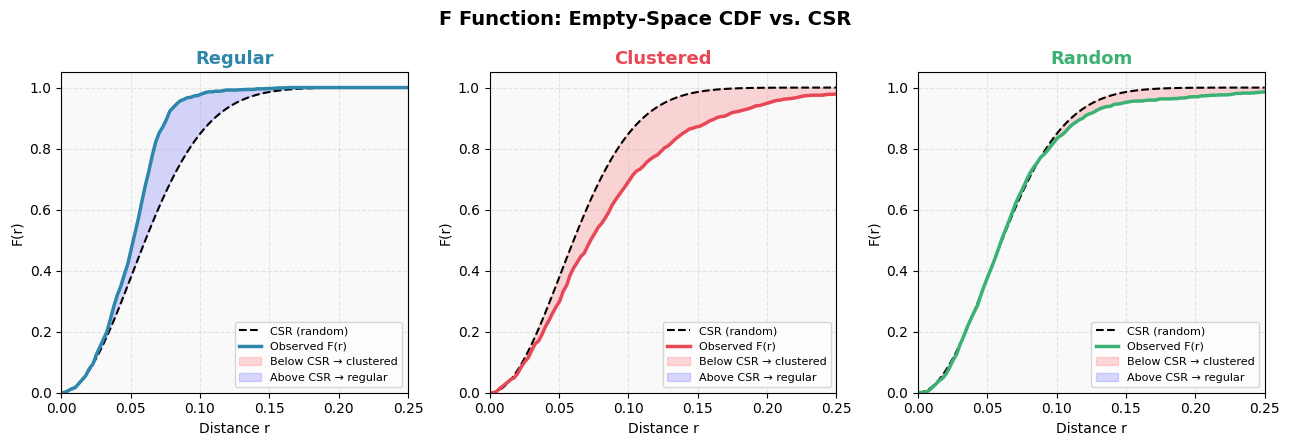

In [20]:
def f_function(points, r_max=0.25, n_bins=100, n_random=1000):
    """Empirical F(r): CDF of distances from random locations to nearest event."""
    rand_pts = np.random.uniform(0, 1, (n_random, 2))
    D = cdist(rand_pts, points).min(axis=1)
    r = np.linspace(0, r_max, n_bins)
    F = np.array([np.mean(D <= ri) for ri in r])
    return r, F

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), facecolor="white")
for ax, (name, pts, col) in zip(axes, patterns):
    r, F_obs = f_function(pts)
    ax.plot(r_vals, G_random_theory, "k--", lw=1.5, label="CSR (random)")
    ax.plot(r, F_obs, color=col, lw=2.5, label="Observed F(r)")
    ax.fill_between(r, F_obs, g_csr(r, N),
                    where=(F_obs < g_csr(r, N)),
                    alpha=0.15, color="red",  label="Below CSR → clustered")
    ax.fill_between(r, F_obs, g_csr(r, N),
                    where=(F_obs > g_csr(r, N)),
                    alpha=0.15, color="blue", label="Above CSR → regular")
    ax.set_title(name, fontsize=13, fontweight="bold", color=col)
    ax.set_xlabel("Distance r"); ax.set_ylabel("F(r)")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 0.25); ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_facecolor("#f9f9f9")

fig.suptitle("F Function: Empty-Space CDF vs. CSR", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 2d. Aggregation Index — Clark-Evans R statistic

In [ ]:
def clark_evans_R(points, area=1.0):
    """
    Clark-Evans Nearest-Neighbor Index (1954).
    R = d̄_obs / d̄_exp,  where d̄_exp = 0.5 / sqrt(n / area)

    R < 1  → clustered (points closer together than random)
    R ≈ 1  → random (Complete Spatial Randomness, CSR)
    R > 1  → dispersed / regular (points farther apart than random)
    R_max ≈ 2.149  →  perfect hexagonal lattice

    """
    n = len(points)
    D = cdist(points, points)
    np.fill_diagonal(D, np.inf)
    d_obs = D.min(axis=1).mean()              # mean nearest-neighbor distance
    d_exp = 0.5 / np.sqrt(n / area)           # CSR expected mean NND
    return d_obs / d_exp

for name, pts, _ in patterns:
    R = clark_evans_R(pts)
    if R < 0.85:
        interp = "clustered"
    elif R > 1.15:
        interp = "dispersed / regular"
    else:
        interp = "random (CSR)"
    print(f"  {name:12s}: R = {R:.4f}  →  {interp}")


  Regular     : R = 1.8582  →  dispersed / regular
  Clustered   : R = 0.7916  →  clustered
  Random      : R = 1.1197  →  random (CSR)


# ─────────────────────────────────────────────────────────────────────────────
# 2e. Monte Carlo permutation test for clustering

  Running 999 CSR simulations …
  Regular     : obs mean NND = 0.1199, p = 0.000
  Clustered   : obs mean NND = 0.0529, p = 0.002
  Random      : obs mean NND = 0.0723, p = 0.430


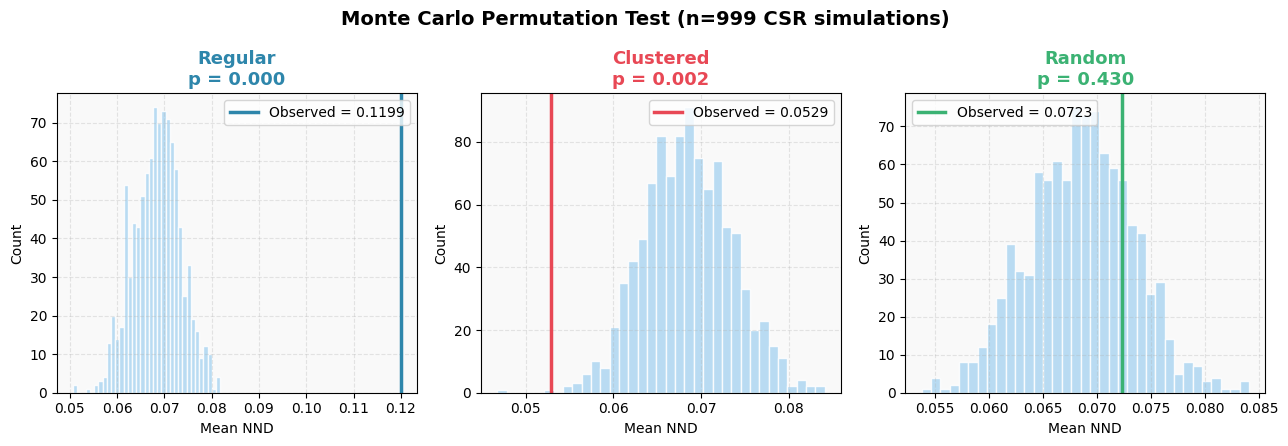

In [ ]:

def mean_nnd(points):
    """Mean nearest-neighbor distance."""
    D = cdist(points, points)
    np.fill_diagonal(D, np.inf)
    return D.min(axis=1).mean()

n_sims = 999
print(f"  Running {n_sims} CSR simulations …")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), facecolor="white")
for ax, (name, pts, col) in zip(axes, patterns):
    obs_stat = mean_nnd(pts)
    sim_stats = [mean_nnd(np.random.uniform(0, 1, (N, 2))) for _ in range(n_sims)]
    sim_stats = np.array(sim_stats)

    # p-value: fraction of sims with smaller (more clustered) mean NND
    p_low  = np.mean(sim_stats <= obs_stat)   # clustered tail
    p_high = np.mean(sim_stats >= obs_stat)   # regular tail
    p_val  = min(p_low, p_high) * 2           # two-tailed (cap at 1)

    ax.hist(sim_stats, bins=35, color="#AED6F1", edgecolor="white", alpha=0.85)
    ax.axvline(obs_stat, color=col, linewidth=2.5,
                label=f"Observed = {obs_stat:.4f}")
    ax.set_title(f"{name}\np = {p_val:.3f}", fontsize=13, fontweight="bold", color=col)
    ax.set_xlabel("Mean NND"); ax.set_ylabel("Count")
    ax.legend(fontsize=10)
    ax.set_facecolor("#f9f9f9")
    ax.grid(True, linestyle="--", alpha=0.3)
    print(f"  {name:12s}: obs mean NND = {obs_stat:.4f}, p = {p_val:.3f}")

fig.suptitle(f"Monte Carlo Permutation Test (n={n_sims} CSR simulations)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 2f. All three patterns side-by-side (with Clark-Even R)

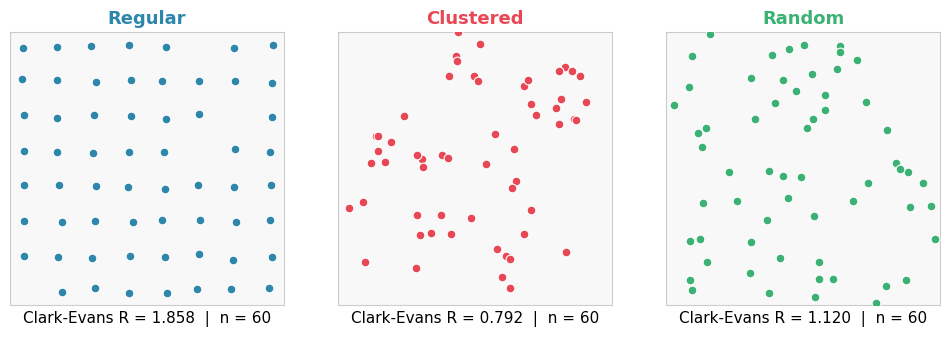

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor="white")
for ax, (name, pts, col) in zip(axes, patterns):
    ax.scatter(pts[:, 0], pts[:, 1], c=col, s=40,
                edgecolors="white", linewidth=0.8, zorder=3)
    ax.set_title(name, fontsize=13, fontweight="bold", color=col)
    ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor("#cccccc")
    ax.set_facecolor("#f8f8f8")
    R = clark_evans_R(pts)
    ax.set_xlabel(f"Clark-Evans R = {R:.3f}  |  n = {N}", fontsize=11)


# Practice: Can you calculate the G function, F function, and Clark-Evans R statistics for the earthquakes dataset?

## In this analysis, we specifically focus on the Japan / NW Pacific region  with the region (25–50 °N, 125–150 °E)

In [43]:
from pyproj import Transformer
def project_points(lons, lats, target_epsg):
    """Reproject WGS-84 lon/lat to a metric CRS. Returns (x_km, y_km)."""
    transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{target_epsg}",
                                       always_xy=True)
    x_m, y_m = transformer.transform(lons, lats)
    return x_m / 1000.0, y_m / 1000.0   # → kilometres

In [44]:
eq_df_jp = eq_df[(eq_df['latitude']<50) &
                 (eq_df['latitude']>25) &
                 (eq_df['longitude']<150) &
                 (eq_df['longitude']>125)]
# convert latitude/longitude into kilometers
x_km, y_km = project_points(eq_df_jp['longitude'],eq_df_jp['latitude'],target_epsg=32654)
eq_df_jp['x_km'] = x_km
eq_df_jp['y_km'] = y_km

/workspaces/.venv/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


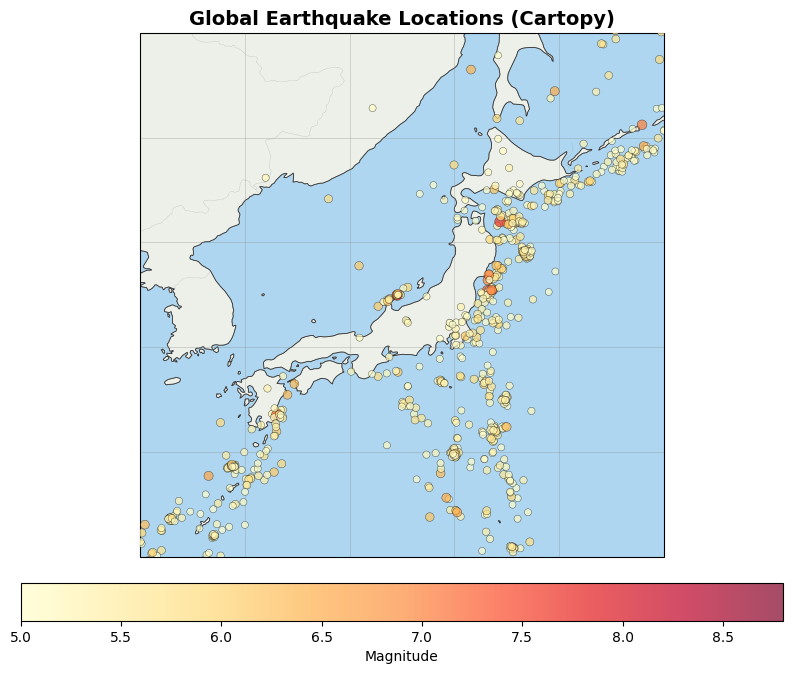

In [45]:
fig, ax = plt.subplots(figsize=(13, 7),
                        subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([125,150,25,50],crs=ccrs.PlateCarree()) #[lon_min, lon_max, lat_min, lat_max]
ax.add_feature(cfeature.OCEAN,     facecolor="#AED6F1")
ax.add_feature(cfeature.LAND,      facecolor="#ECF0E8", edgecolor="#888888", linewidth=0.4)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color="#333333")
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":", color="#888888")
ax.gridlines(linewidth=0.4, color="gray", alpha=0.5)

sc = ax.scatter(
    eq_df["longitude"], eq_df["latitude"],
    c=eq_df["magnitude"], cmap="YlOrRd",
    s=eq_df["magnitude"] ** 2,              # size ~ magnitude²
    alpha=0.7, transform=ccrs.PlateCarree(),
    zorder=5, linewidths=0.3, edgecolors="black",
)
cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.04, shrink=0.6)
cbar.set_label("Magnitude")
ax.set_title("Global Earthquake Locations (Cartopy)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()